<div align="left" style="background-color: #008080; padding: 20px 10px;">
<h3><b>IDEAS - Institute of Data Engineering, Analytics and Science Foundation</b></h3>
<p>Summer Internship Program 2026</p>
<hr style="width:100%;">
<h3><b>Project Title:</b> Data analysis with house sales data.</h3>
<h4>Project Notebook</h4>

<blockquote style="border-left: 4px solid #4285F4; padding-left: 15px;">
  <strong>Created by:</strong> Koulika Paul<br>
  <strong>Designation:</strong> Project Linked Associate Research Engineer in Statistics
</blockquote>
<hr style="width:100%;">
</div>

### Question 1: Import Libraries and Load Data (2 Marks)

Import `pandas` as `pd` and `numpy` as `np`. Download the data `house_price_india.csv` from https://drive.google.com/drive/folders/1gieHICVDBbUKMZiSF4YRQMAJic-w50JM?usp=sharing and load the dataset into a DataFrame called `house_data` and display its first 5 rows.

**Expected Output:** A table showing the first 5 rows of the house price dataset.


In [17]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# 2. Set the path to your file
# NOTE: You will need to update this path to exactly where the file is in your Drive.
path = '/content/drive/MyDrive/house_price_india.xlsx'

# If you uploaded the raw excel file instead of the CSV, use this line instead:
# df = pd.read_excel('/content/drive/MyDrive/house_price_india.xlsx')

# 3. Load the dataset
df = pd.read_excel('/content/drive/MyDrive/house_price_india.xlsx')

# 4. Basic checks
print("Data Shape:", df.shape)

# 5. Clean up
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 6. Split into X and y
y = df['Price']
X = df.drop(columns=['Price'])

print("X shape:", X.shape)
print("y shape:", y.shape)
house_data = pd.read_excel(path)

# Display the first 5 rows
house_data.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data Shape: (14620, 23)
X shape: (14620, 21)
y shape: (14620,)


,id,Date,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
0,6762810145,42491,5,2.50,3650,9050,2.0,0,4,5,...,1921,0,122003,52.8645,-114.557,2880,5400,2,58,2380000
1,6762810635,42491,4,2.50,2920,4000,1.5,0,0,5,...,1909,0,122004,52.8878,-114.470,2470,4000,2,51,1400000
2,6762810998,42491,5,2.75,2910,9480,1.5,0,0,3,...,1939,0,122004,52.8852,-114.468,2940,6600,1,53,1200000
3,6762812605,42491,4,2.50,3310,42998,2.0,0,0,3,...,2001,0,122005,52.9532,-114.321,3350,42847,3,76,838000
4,6762812919,42491,3,2.00,2710,4500,1.5,0,0,4,...,1929,0,122006,52.9047,-114.485,2060,4500,1,51,805000


### Question 2: Data Inspection (2 Marks)

Inspect the `house_data` DataFrame. Print its shape to see the number of rows and columns, and then check for the total number of duplicate rows in the dataset.

**Expected Output:** The shape of the DataFrame (e.g., `(14620, 23)`) and the total count of duplicate rows.


In [18]:
# 1. Print the shape of the DataFrame
print("Shape of the DataFrame:", house_data.shape)

# 2. Check for the total number of duplicate rows
duplicate_count = house_data.duplicated().sum()
print("Total number of duplicate rows:", duplicate_count)

Shape of the DataFrame: (14620, 23)
Total number of duplicate rows: 0


### Question 3: Data Types and Missing Values (1 Marks)

Display the data types of all columns in the `house_data` DataFrame. Then, calculate and print the total number of missing (null) values for each column.

**Expected Output:** A list of columns with their data types, followed by a list of columns and their respective missing value counts.

In [19]:
# Display data types of all columns
print("Data Types of all columns:")
print(house_data.dtypes)

# Calculate and print missing values for each column
print("\nTotal Missing Values per column:")
print(house_data.isnull().sum())

Data Types of all columns:
id                                         int64
Date                                       int64
number of bedrooms                         int64
number of bathrooms                      float64
living area                                int64
lot area                                   int64
number of floors                         float64
waterfront present                         int64
number of views                            int64
condition of the house                     int64
grade of the house                         int64
Area of the house(excluding basement)      int64
Area of the basement                       int64
Built Year                                 int64
Renovation Year                            int64
Postal Code                                int64
Lattitude                                float64
Longitude                                float64
living_area_renov                          int64
lot_area_renov                            

### Question 4: Column Cleanup (1 Marks)

Drop the following columns from the `house_data` DataFrame as they are not needed for this analysis: 'Date', 'Longitude', 'Renovation Year', 'Postal Code', 'Lattitude', 'living_area_renov', 'lot_area_renov'. Print the remaining columns.

**Expected Output:** A printed Index object showing the list of remaining column names.

In [20]:
# Drop unnecessary columns
columns_to_drop = ['Date', 'Longitude', 'Renovation Year', 'Postal Code',
                   'Lattitude', 'living_area_renov', 'lot_area_renov']

house_data = house_data.drop(columns=columns_to_drop)

# Print remaining columns
print("Remaining columns:")
print(house_data.columns)

Remaining columns:
Index(['id', 'number of bedrooms', 'number of bathrooms', 'living area',
       'lot area', 'number of floors', 'waterfront present', 'number of views',
       'condition of the house', 'grade of the house',
       'Area of the house(excluding basement)', 'Area of the basement',
       'Built Year', 'Number of schools nearby', 'Distance from the airport',
       'Price'],
      dtype='object')


### Question 5: Descriptive Statistics (1 Marks)

Generate and display the descriptive statistics for only the numerical columns of the cleaned `house_data` DataFrame.

**Expected Output:** A table showing count, mean, std, min, 25%, 50%, 75%, and max for the numerical columns.


In [21]:
# Generate descriptive statistics for numerical columns
house_data.describe()

,id,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),Area of the basement,Built Year,Number of schools nearby,Distance from the airport,Price
count,1.462000e+04,14620.000000,14620.000000,14620.000000,1.462000e+04,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,14620.000000,1.462000e+04
mean,6.762821e+09,3.379343,2.129583,2098.262996,1.509328e+04,1.502360,0.007661,0.233105,3.430506,7.682421,1801.783926,296.479070,1970.926402,2.012244,64.950958,5.389322e+05
std,6.237575e+03,0.938719,0.769934,928.275721,3.791962e+04,0.540239,0.087193,0.766259,0.664151,1.175033,833.809963,448.551409,29.493625,0.817284,8.936008,3.675324e+05
min,6.762810e+09,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,4.000000,370.000000,0.000000,1900.000000,1.000000,50.000000,7.800000e+04
25%,6.762815e+09,3.000000,1.750000,1440.000000,5.010750e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1200.000000,0.000000,1951.000000,1.000000,57.000000,3.200000e+05
50%,6.762821e+09,3.000000,2.250000,1930.000000,7.620000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1580.000000,0.000000,1975.000000,2.000000,65.000000,4.500000e+05
75%,6.762826e+09,4.000000,2.500000,2570.000000,1.080000e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2240.000000,580.000000,1997.000000,3.000000,73.000000,6.450000e+05
max,6.762832e+09,33.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,3.000000,80.000000,7.700000e+06


### Question 6: Group by Bedrooms (1 Marks)

Group the `house_data` DataFrame by the 'number of bedrooms' and calculate the average price for each group. Display the resulting Series.

**Expected Output:** A Pandas Series with the number of bedrooms as the index and the average price as the values.

In [22]:
# Group by number of bedrooms and calculate average price
avg_price_by_bedrooms = house_data.groupby('number of bedrooms')['Price'].mean()

print("Average Price by Number of Bedrooms:")
print(avg_price_by_bedrooms)

Average Price by Number of Bedrooms:
number of bedrooms
1     3.089638e+05
2     3.985476e+05
3     4.632776e+05
4     6.361988e+05
5     7.752550e+05
6     8.375815e+05
7     1.016544e+06
8     1.208455e+06
9     7.766663e+05
10    8.200000e+05
11    5.200000e+05
33    6.400000e+05
Name: Price, dtype: float64


### Question 7: Houses with Waterfront (1 Marks)

Calculate the total number of houses that have a waterfront view. Then, calculate the average price of houses with a waterfront view versus those without.

**Expected Output:** The count of houses with and without waterfronts, followed by their average prices.


In [23]:
# Count of houses with and without waterfront view
print("Count of Houses by Waterfront View:")
print(house_data['waterfront present'].value_counts())

# Average price: waterfront vs non-waterfront
print("\nAverage Price by Waterfront View:")
print(house_data.groupby('waterfront present')['Price'].mean())

Count of Houses by Waterfront View:
waterfront present
0    14508
1      112
Name: count, dtype: int64

Average Price by Waterfront View:
waterfront present
0    5.304174e+05
1    1.641902e+06
Name: Price, dtype: float64


### Question 8: Feature Selection based on Correlation (2 Marks)

Calculate the correlation of all numerical features with the 'Price' column. Create a list named `highly_correlated_features` containing the names of features that have a correlation with 'Price' greater than 0.5. Print this list.

**Hint:** First calculate the full correlation matrix with `.corr()`. Then, select the 'Price' column from it. Filter this series to find features where the correlation value is > 0.5 and get their index.

**Expected Output:** A list of strings, where each string is the name of a highly correlated feature.

In [24]:
# Calculate correlation of all features with 'Price'
correlation_with_price = house_data.corr()['Price']

# Filter features with correlation > 0.5 (excluding 'Price' itself)
highly_correlated_features = correlation_with_price[
    (correlation_with_price > 0.5) & (correlation_with_price.index != 'Price')
].index.tolist()

print("Highly Correlated Features with Price (correlation > 0.5):")
print(highly_correlated_features)

Highly Correlated Features with Price (correlation > 0.5):
['number of bathrooms', 'living area', 'grade of the house', 'Area of the house(excluding basement)']


### Question 9: Prepare Data for Modeling (1 Marks)

Using the `highly_correlated_features` list from the previous question, create your feature matrix `X`. Your target vector `y` should be the 'Price' column. Then, split `X` and `y` into training and testing sets with a `test_size` of 0.3 and a `random_state` of 123.

**Expected Output:** No direct output. The variables `X_train`, `X_test`, `y_train`, and `y_test` will be created.

In [25]:
from sklearn.model_selection import train_test_split

# Q8 - Recalculate highly correlated features
correlation_with_price = house_data.corr()['Price']
highly_correlated_features = correlation_with_price[
    (correlation_with_price > 0.5) & (correlation_with_price.index != 'Price')
].index.tolist()

# Q9 - Create feature matrix and split
X = house_data[highly_correlated_features]
y = house_data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (10234, 4)
X_test shape: (4386, 4)
y_train shape: (10234,)
y_test shape: (4386,)


### Question 10: Train and Evaluate a Linear Regression Model (5 Marks)

Import `LinearRegression` from `sklearn.linear_model` and `r2_score` from `sklearn.metrics`. Train a linear regression model on your training data. Make predictions on the test data and print the R-squared score.

**Expected Output:** A single decimal number representing the R-squared score of the model.


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Create feature matrix X and target vector y
X = house_data[highly_correlated_features]
y = house_data['Price']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and print R-squared score
y_pred = model.predict(X_test)

print("R-squared Score:", r2_score(y_test, y_pred))

R-squared Score: 0.5628903560152543


### Question 11: K-Means Clustering (5 Marks)

Import `KMeans` from `sklearn.cluster`. Initialize and fit the K-Means clustering model on the MNIST features (`X`).
Since we know there are 10 digits (0-9), set the number of clusters to 10. Assign the cluster labels to a variable `kmeans_labels`.

**Expected Output:** A successfully fitted K-Means model and the cluster labels array.


In [27]:
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_openml

# Load MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data
y = mnist.target

print("MNIST Data Shape:", X.shape)

# Initialize and fit K-Means with 10 clusters (one per digit 0-9)
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X)

# Assign cluster labels
kmeans_labels = kmeans.labels_

print("Cluster Labels:", kmeans_labels)
print("Cluster Labels Shape:", kmeans_labels.shape)

MNIST Data Shape: (70000, 784)
Cluster Labels: [5 9 8 ... 2 4 3]
Cluster Labels Shape: (70000,)


### Question 12: F1 Score Evaluation for Clustering (5 Marks)

Evaluate the clustering performance using the F1 score. Since K-Means assigns arbitrary cluster labels, you will first need to map each cluster label to the most frequent true label in that cluster.
After mapping the labels, calculate and print the macro-averaged F1 score using `sklearn.metrics.f1_score`.

**Expected Output:** The calculated F1 score of the clustering.


In [28]:
import numpy as np
from sklearn.metrics import f1_score

# Map each cluster label to the most frequent true label in that cluster
y = y.astype(int)  # ensure true labels are integers

mapped_labels = np.zeros_like(kmeans_labels)

for cluster in range(10):
    # Get indices of all points in this cluster
    cluster_indices = np.where(kmeans_labels == cluster)[0]

    # Find the most frequent true label in this cluster
    true_labels_in_cluster = y[cluster_indices]
    most_frequent_label = np.bincount(true_labels_in_cluster).argmax()

    # Map this cluster to that label
    mapped_labels[cluster_indices] = most_frequent_label

# Calculate macro-averaged F1 score
f1 = f1_score(y, mapped_labels, average='macro')
print("Macro-averaged F1 Score:", f1)

Macro-averaged F1 Score: 0.5224031481950627


### Question 13: Confusion Matrix for Clustering (3 Marks)

Generate and display the confusion matrix comparing your mapped cluster labels (from Question 9) to the true labels (`y`). Use `confusion_matrix` from `sklearn.metrics`. This helps evaluate how well your clusters align with the actual digit classes without requiring visual plotting.

**Expected Output:** A 10x10 confusion matrix printed as an array or a Pandas DataFrame.

Confusion Matrix:
        Predicted 0  Predicted 1  Predicted 2  Predicted 3  Predicted 4  \
True 0         5053            6            9          290           39   
True 1            0         7819           10            8            7   
True 2           57          859         4863          323          216   
True 3           24          507          217         4581          193   
True 4            9          412           29            0         3728   
True 5           60          435            7         2129          432   
True 6           71          235           53           38           67   
True 7           21          686           53            6         2094   
True 8           36          665           53         1212          208   
True 9           51          356           19           87         3462   

        Predicted 5  Predicted 6  Predicted 7  Predicted 8  Predicted 9  
True 0            0         1427            7           72            0  
True 1  

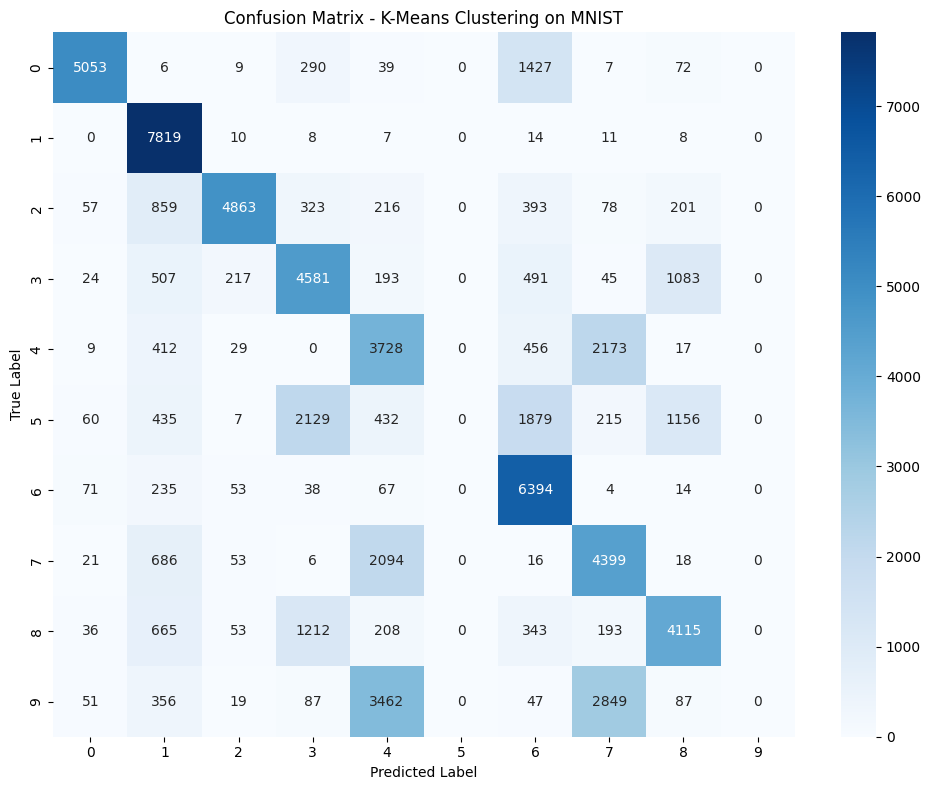

In [29]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Generate confusion matrix
cm = confusion_matrix(y, mapped_labels)

# Display as a labeled DataFrame for better readability
cm_df = pd.DataFrame(cm,
                     index=[f'True {i}' for i in range(10)],
                     columns=[f'Predicted {i}' for i in range(10)])

print("Confusion Matrix:")
print(cm_df)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y, mapped_labels)

# Plot colored confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))

plt.title('Confusion Matrix - K-Means Clustering on MNIST')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()